## In-Class Guided Exercise:
:

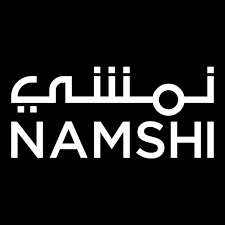

Let us web scrape Namshi site

### Import needed libraries


In [3]:
import requests
import httpx  # if you want to use httpx instead of requests

import pandas as pd
from bs4 import BeautifulSoup
from time import sleep
import requests



### Steps on using BeautifulSoup:
#### 1. Use `requests` to access the url of the web page you want to scrape

In [4]:
url='https://www.namshi.com/bahrain-en/kids-shoes-boys/?page=1'


In [5]:
# html_page = requests.get(url)


# if you get error or run forever, then:
# 1. Stop or kill the kernel
# 2. comment the above line
# 3. uncomment the below two lines 
# 4. run everything from the begining including this cell 

hdr={"user-agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.3.0.1922 (beta) Yowser/2.5 Safari/537.3-449"}
html_page = requests.get(url,headers=hdr)



In [6]:
# check the status code if it is 200 then everthing is OK
html_page.status_code
# 200 mean OK 

200

In [7]:
html_page.text[:300]

'<!DOCTYPE html><html lang="en" dir="ltr" style="min-width:1250px" data-version="" data-commit="1a0d6c1"><head><meta charSet="utf-8"/><meta name="viewport" content="width=device-width, initial-scale=1"/><meta name="viewport" content="width=device-width, initial-scale=1.0, maximum-scale=3.0"/><link re'

#### 2. Now that we have the web page, we can parse it with beautifulsoup:

In [8]:
soup = BeautifulSoup(html_page.text, 'html.parser') 


- Get the title of the page using the tag 'title':

In [9]:
soup.title.text

"Boys' Shoes Bahrain | Best Price Offers | Manama, Riffa"

#### 3. Get all the items in that page
- Use `inspect` on the web page to know how to collect the items 
- Create a variable that contains all the items in that web page


In [10]:
namshi = soup.find_all('div' , class_="ProductBox_container__wiajf ProductBox_boxContainer__p7PaQ")


In [11]:
# check one of the items collected
namshi[0]

<div class="ProductBox_container__wiajf ProductBox_boxContainer__p7PaQ"><a class="ProductBox_container__wiajf" href="/bahrain-en/buy-adidas-youth-barreda-decode/Z9102CE43ABF384A17DADZ/p/"><div class="ProductBox_imageContainer__qrIJP"><div class="ProductBox_productBadgeContainer__WbLpW"><section class="ProductBadge_container__m6RwS ProductBadge_regular__n49O_">Unisex</section></div><div><section><div class="EmblaCarousel_outerWrapper__wzwd8"><div class="EmblaCarousel_wrapper__ndTTF"><div class="EmblaCarousel_container__MkuxD"><div class="EmblaCarousel_carouselContainer__C7YLK"><div class="EmblaCarousel_slidesContainer__NYcld"><div style="flex:0 0 calc(100%)"><div class="ProductImage_imageContainer__B5pcR"><img alt="Adidas Youth Barreda Decode" class="ProductImage_image__Gv0_w ProductImage_outlined__NEzjp" data-nimg="1" decoding="async" fetchpriority="high" height="1091" loading="eager" src="https://f.nooncdn.com/p/pzsku/Z9102CE43ABF384A17DADZ/45/_/1776094505/c86e366f-86c5-4156-b424-3ea7

#### 4. Using one item, try to collect the information that you want to scrape
- In our web page here, we want to collect the following:
    - Product Title
    - Brand
    - Price
    - Currency
    - PreReduction Price
    - Discount



##### 4.1 *Get the Product Title*  

In [12]:
namshi[0].find('div' , class_="ProductBox_productTitle__6tQ3b").text

'Youth Barreda Decode'

##### 4.2 *Get the Brand*

In [13]:
namshi[0].find( 'div', class_="OutletAndBrand_brandAndOutletTag__eEj4l").text

'Adidas'

##### 4.3 *Get the Price*

In [14]:
namshi[0].find( 'span' , class_="ProductPrice_value__YcE7Z").text

'18.33'

##### 4.4 *Get the Currency*

In [15]:
namshi[0].find('span' , class_="ProductPrice_currency__zHaox").text

'BHD'

##### 4.5 *Get the PreReduction Price*

In [16]:
namshi[1].find( 'div' , class_="ProductPrice_preReductionPrice__oM4c9 ProductPrice_large__e_5W8").text


AttributeError: 'NoneType' object has no attribute 'text'

##### 4.6 *Get the Discount*

In [ ]:
namshi[1].find('span' , class_="DiscountTag_value__SofQj" ).text

#### 5. Collect all the information of all the items using `loops`
- Now, once we know how to get in information we want from one item, we can now collect all the information from all the items using `for loop`
- First of all, we need to create a list for each info we want to collect and append the scraped info to those lists

In [ ]:
# define empty lists for your collections

title = [] 
brand = [] 
price = [] 
currency= []
pre_price =[]
discount = []
# your code here

for i in namshi:
    try: title.append(i.find('div', class_='ProductBox_productTitle__6tQ3b').text) 
    except: title.append(None)
    try: price.append(i.find('span',class_='ProductPrice_value__YcE7Z').text) 
    except: price.append(None) 
    try: brand.append(i.find('div',class_='OutletAndBrand_brandAndOutletTag__eEj4l').text) 
    except: brand.append(None) 
    try: currency.append(i,find('span',class_='ProductPrice_currency__zHaox').text) 
    except: currency.append(None) 
    try: pre_price.append(i.find('div', class_='ProductPrice_preReductionPrice__oM4c9').text) 
    except: pre_price.append(None) 
    try: discount.append(i.find('div', class_='ProductPrice_preReductionPrice__oM4c9').text) 
    except: discount.append(None)

In [ ]:
# check what one of the lists contains
price

#### 6. Modify the previous `loop` to collect multiple web pages 
- In below code, we collect the web pages from 1 to 5 of that site
- Notice that the only difference from page to page is the page number which we can use in the `for loop` with the formatted text f"

In [ ]:
hdr={"user-agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 YaBrowser/23.3.0.1922 (beta) Yowser/2.5 Safari/537.3-449"}

# define empty lists for your collections
title = [] 
brand = [] 
price = [] 
currency = []
pre_price = []
discount = []

for p in range(1, 6):
    url = f"https://www.namshi.com/bahrain-en/kids-shoes-boys/?page={p}"
    
    page = requests.get(url, headers=hdr)
    soup = BeautifulSoup(page.text, 'html.parser')
    namshi = soup.find_all('div', class_="ProductBox_container__wiajf ProductBox_boxContainer__p7PaQ")

    for i in namshi:
        try:
            tag = title.append(i.find('div', class_='ProductBox_productTitle__6tQ3b').text.strip())
        except:
            title.append(tag if tag else None)
            
        try:
            current_p = price.append(i.find('span', class_='ProductPrice_value__YcE7Z').text.strip())
        except:
            price.append(current_p if current_p else None)
            
        try:
            brand_name = brand.append(i.find('div', class_='OutletAndBrand_brandAndOutletTag__eEj4l').text.strip())
            
        except:
            brand.append(brand_name if brand_name else None)
            
        try:
            cur =currency.append(i.find('span', class_='ProductPrice_currency__zHaox').text.strip())
        except:
            currency.append(cur if cur else None)
            
        try:
            pp = pre_price.append(i.find('div', class_='ProductPrice_preReductionPrice__oM4c9').text.strip())
        except:
            pre_price.append(pp if pp else None )
            
        try:
            dis = discount.append(i.find('span', class_='DiscountTag_value__SofQj').text.strip())
        except:
            discount.append(dis if dis else None)

#### 7. Create a DataFrame to save all the scraped info. into a table.


In [ ]:
namshi_df = pd.DataFrame({
    'Title': title,
    'Price': brand,
    'brand': price,
    'currency': currency,
    'pre_price': pre_price,
    'discount': discount
})


In [ ]:
# display your dataframe
namshi_df

#### 8. Save your dataframe to a `CSV` file
- Save the output to a csv file (excluding the index)

In [2]:
# Save the output to a csv file (excluding the index)
namshi_df.to_csv("nam.csv",index=False)

